In [223]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api.types import is_numeric_dtype

In [ ]:
df = pd.read_csv('datasets/churn-modelling.csv')

In [225]:
print(f"Rows: {df.shape[0]}\nColumns: {df.shape[1]}")

Rows: 10000
Columns: 14


In [226]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [227]:
# Drop useless columns

df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [228]:
df.isnull().sum()

,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


In [229]:
df_skew_cpy = df.select_dtypes(include='number').copy()
df_skew_cpy.skew()

,0
CreditScore,-0.071607
Age,1.011320
Tenure,0.010991
Balance,-0.141109
NumOfProducts,0.745568
HasCrCard,-0.901812
IsActiveMember,-0.060437
EstimatedSalary,0.002085
Exited,1.471611


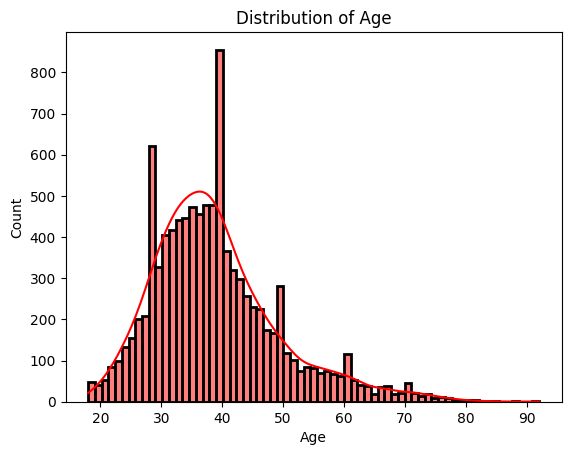

In [230]:
# Plot the distribution of the 'age column'

plt.title("Distribution of Age")
sns.histplot(data=df, x='Age', kde=True, color='red', linewidth=2, edgecolor='black')
plt.show()

NOTE: No need to log transform

In [231]:
# Encode the columns

from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False).set_output(transform='pandas')
one_hot_cols = ['Geography', 'Gender']

res = ohe.fit_transform(df[one_hot_cols])

exited_cpy = df['Exited']

df.drop('Exited', axis=1, inplace=True)
df.drop(columns=one_hot_cols, axis=1, inplace=True)

df = pd.concat([df, res], axis=1)
df = pd.concat([df, exited_cpy], axis=1)

df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,Exited
0,619,42,2,0.00,1,1,1,101348.88,1.0,0.0,0.0,1.0,0.0,1
1,608,41,1,83807.86,1,0,1,112542.58,0.0,0.0,1.0,1.0,0.0,0
2,502,42,8,159660.80,3,1,0,113931.57,1.0,0.0,0.0,1.0,0.0,1
3,699,39,1,0.00,2,0,0,93826.63,1.0,0.0,0.0,1.0,0.0,0
4,850,43,2,125510.82,1,1,1,79084.10,0.0,0.0,1.0,1.0,0.0,0


In [232]:
# Split the dataset into training and testing

from sklearn.model_selection import train_test_split

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [233]:
# Standard scale the training and testing data

from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)

In [234]:
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [235]:
model = Sequential()
model.add(Dense(3, activation='sigmoid', input_dim=X.shape[1]))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [236]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 3)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46 (184.00 B)

 Trainable params: 46 (184.00 B)

 Non-trainable params: 0 (0.00 B)

In [237]:
model.compile(loss='binary_crossentropy', optimizer='Adam')

In [238]:
model.fit(X_train_scaled, y_train)

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6194


In [239]:
y_pred = model.predict(X_test_scaled)
y_pred = (y_pred > 0.5).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


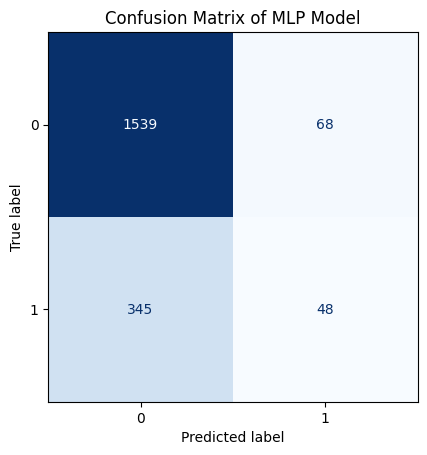

In [241]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', colorbar=False)
plt.title("Confusion Matrix of MLP Model")
plt.show()